## 📌 How to Use This Notebook

This notebook contains the computational models for Phase 1 and Phase 2 of the ES 671 End-Semester Project.

### **1. Dependencies**
Ensure your Python environment has the following standard libraries installed:
* `numpy`
* `matplotlib`

### **2. Execution**
* The code is completely self-contained. Simply select **"Run All"** (or execute the cells sequentially).
* The final cell contains an execution block (`if __name__ == "__main__":`) that automatically runs all four project questions (`question1()` through `question4()`) in order.

### **3. Modifying Inputs**
If you wish to test different parameters, you can easily modify them in the code:
* **Material Properties:** Base moduli and strengths ($E_1$, $E_2$, $F_{1t}$, etc.) are defined in the **Global Base Properties** section right before the question functions.
* **Layups & Loads:** Laminate stacking sequences, thicknesses, and applied loads ($N$, $M$) are defined locally within their respective function blocks (`question1()`, `question2()`, etc.).

### **4. Outputs**
* **Console:** Matrices ($[A], [B], [D]$), tabular stress/strain data, and max coupling ratios will print directly to the cell output.
* **Visualizations:** `matplotlib` will automatically generate inline plots for failure criteria envelopes, thickness distributions, and coupling coefficient variations.

--- RUNNING PHASE 1 ---

Material Properties: 
E1 =  38600000000.0 
E2 =  8270000000.0 
nu12 =  0.26 
G12 =  4140000000.0 
Theta =  60.0

Compliance: 
 [[ 2.59067358e-11 -6.73575130e-12  0.00000000e+00]
 [-6.73575130e-12  1.20918984e-10  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  2.41545894e-10]]

Stiffness: 
 [[3.91672679e+10 2.18179947e+09 0.00000000e+00]
 [2.18179947e+09 8.39153640e+09 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.14000000e+09]]

Transformed Compliance: 
 [[ 1.12400048e-10 -2.19698771e-11 -2.35506572e-11]
 [-2.19698771e-11  6.48939237e-11 -5.87323637e-11]
 [-2.35506572e-11 -5.87323637e-11  1.80609390e-10]]

Transformed Stiffness: 
 [[1.10913683e+10 7.17590047e+09 3.77979576e+09]
 [7.17590047e+09 2.64792340e+10 9.54648687e+09]
 [3.77979576e+09 9.54648687e+09 9.13410100e+09]]

Material Properties: 
E1 =  38600000000.0 
E2 =  8270000000.0 
nu12 =  0.26 
G12 =  4140000000.0 
Theta =  60.0

Global Strain: 
 [[0.002]
 [0.002]
 [0.   ]]

Global Stress: 
 [[3653

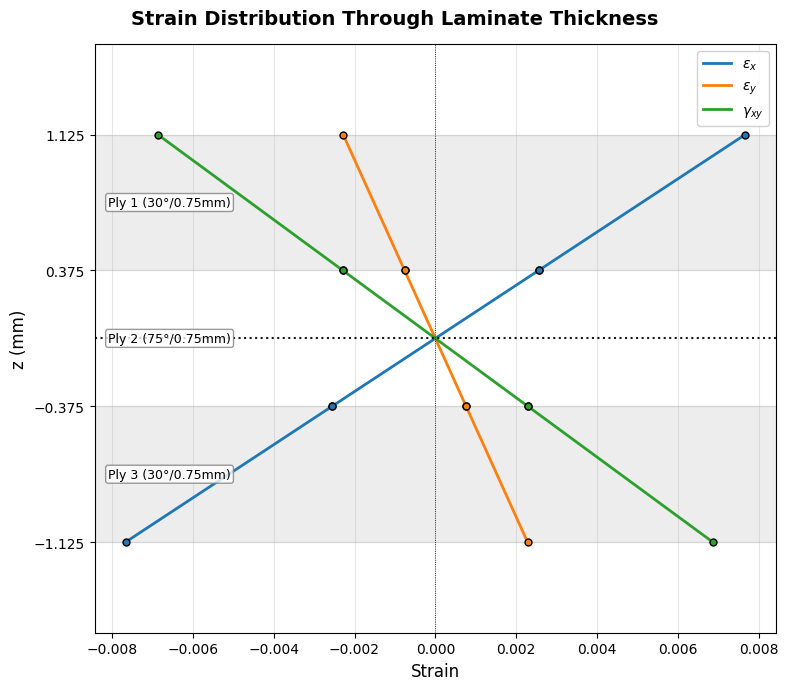

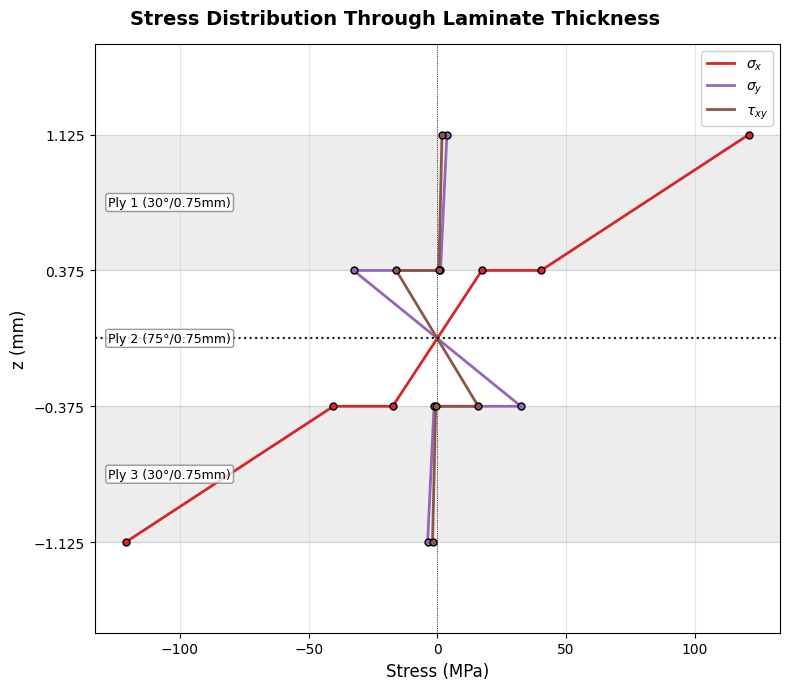

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# PHASE 1: Lamina Properties and Local and Global Transformations

def compute_compliance_and_stiffness(E1, E2, nu12, G12, nu21=None, eta121=0, eta112=0, eta122=0, eta212=0):
    """Computes the local compliance [S] and stiffness [Q] matrices."""
    S11 = 1 / E1 if E1 else None
    S22 = 1 / E2 if E2 else None
    S66 = 1 / G12 if G12 else None

    # S12 and S21
    S12 = None
    if nu12 is not None and E1 is not None:
        S12 = -nu12 / E1
        if nu21 is None: nu21 = nu12 * E2 / E1
    elif nu21 is not None and E2 is not None:
        S12 = -nu21 / E2
        if nu12 is None: nu12 = nu21 * E1 / E2
    S21 = S12

    # S16 and S61
    S16 = None
    if eta121 is not None and E1 is not None:
        S16 = eta121 / E1
    elif eta112 is not None and G12 is not None:
        S16 = eta112 / G12
    S61 = S16

    # S26 and S62
    S26 = None
    if eta122 is not None and E2 is not None:
        S26 = eta122 / E2
    elif eta212 is not None and G12 is not None:
        S26 = eta212 / G12
    S62 = S26

    S = np.array([[S11, S12, S16],
                  [S21, S22, S26],
                  [S61, S62, S66]], dtype=float)

    if np.isnan(S).any():
        raise ValueError("Compliance matrix cannot be filled due to insufficient material properties")

    Q = np.linalg.inv(S)
    return S, Q


def get_transformation_matrices(theta_deg):
    """Returns transformation matrices [T] and [R] for a given angle in degrees."""
    theta = np.deg2rad(theta_deg)
    a, b = np.cos(theta), np.sin(theta)

    T = np.array([
        [a**2, b**2,  2*a*b],
        [b**2, a**2, -2*a*b],
        [-a*b, a*b,   a**2 - b**2]
    ])
    R = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 2]])
    return T, R


def compute_transformed_matrices(S, theta_deg):
    """Computes transformed global compliance [S_bar] and stiffness [Q_bar]."""
    T, R = get_transformation_matrices(theta_deg)
    T_inv = np.linalg.inv(T)
    R_inv = np.linalg.inv(R)

    S_bar = R @ T_inv @ R_inv @ S @ T
    Q_bar = np.linalg.inv(S_bar)
    return S_bar, Q_bar


def compute_lamina_stresses_strains(Q_bar, S, theta_deg, strain_global):
    """Computes global stresses and local strains/stresses given global strains."""
    T, _ = get_transformation_matrices(theta_deg)

    stress_global = Q_bar @ strain_global
    stress_local = T @ stress_global
    strain_local = S @ stress_local
    return stress_global, stress_local, strain_local


def evaluate_failure_criteria(stress_local, strain_local, props):
    """Evaluates 4 failure criteria returning failure flags, modes, and strength ratios."""
    s1, s2, tau12 = stress_local.flatten()
    e1, e2, g12 = strain_local.flatten()

    X1t, X1c, X2t, X2c, S_shear = props['X1t'], props['X1c'], props['X2t'], props['X2c'], props['S']
    e1t, e1c, e2t, e2c, g12m = props['e1t'], props['e1c'], props['e2t'], props['e2c'], props['g12m']
    F12 = props['F12']

    results = {}

    # 1. Maximum Stress Criterion
    failed_stress = True
    if s1 <= X1c or s2 <= X2c: mode_stress = "Failed (Compression)"
    elif s1 >= X1t or s2 >= X2t: mode_stress = "Failed (Tension)"
    elif abs(tau12) >= abs(S_shear): mode_stress = "Failed (Shear)"
    else: failed_stress, mode_stress = False, "Safe"

    R1 = (X1t / s1) if s1 > 0 else (X1c / s1) if s1 < 0 else float('inf')
    R2 = (X2t / s2) if s2 > 0 else (X2c / s2) if s2 < 0 else float('inf')
    R12 = abs(S_shear / tau12) if tau12 != 0 else float('inf')
    results['Max Stress'] = {"failed": failed_stress, "mode": mode_stress, "strength_ratio": min(R1, R2, R12)}

    # 2. Maximum Strain Criterion
    failed_strain = True
    if e1 <= e1c or e2 <= e2c: mode_strain = "Failed (Compression)"
    elif e1 >= e1t or e2 >= e2t: mode_strain = "Failed (Tension)"
    elif abs(g12) >= abs(g12m): mode_strain = "Failed (Shear)"
    else: failed_strain, mode_strain = False, "Safe"

    Re1 = (e1t / e1) if e1 > 0 else (e1c / e1) if e1 < 0 else float('inf')
    Re2 = (e2t / e2) if e2 > 0 else (e2c / e2) if e2 < 0 else float('inf')
    Re12 = abs(g12m / g12) if g12 != 0 else float('inf')
    results['Max Strain'] = {"failed": failed_strain, "mode": mode_strain, "strength_ratio": min(Re1, Re2, Re12)}

    # 3. Tsai-Hill Criterion
    X11 = X1t if s1 > 0 else abs(X1c)
    X22 = X2t if s2 > 0 else abs(X2c)
    fail_val_hill = (s1/X11)**2 - (s1*s2/X11**2) + (s2/X22)**2 + (tau12/S_shear)**2
    failed_hill = fail_val_hill >= 1
    sr_hill = 1 / np.sqrt(fail_val_hill) if fail_val_hill > 0 else float('inf')
    results['Tsai-Hill'] = {"failed": failed_hill, "mode": "Failed" if failed_hill else "Safe", "strength_ratio": sr_hill}

    # 4. Tsai-Wu Criterion
    F1 = 1/X1t + 1/X1c
    F2 = 1/X2t + 1/X2c
    F11 = -1/(X1t*X1c)
    F22 = -1/(X2t*X2c)
    F66 = 1/(S_shear**2)

    fail_val_wu = F1*s1 + F2*s2 + F11*s1**2 + F22*s2**2 + F66*tau12**2 + 2*F12*s1*s2
    failed_wu = fail_val_wu >= 1

    # Solve quadratic for Tsai-Wu Strength Ratio (a*SR^2 + b*SR + c = 0)
    a = F11*s1**2 + F22*s2**2 + F66*tau12**2 + 2*F12*s1*s2
    b = F1*s1 + F2*s2
    c = -1
    if a == 0:
        sr_wu = -c/b if b != 0 else float('inf')
    else:
        discriminant = b**2 - 4*a*c
        if discriminant >= 0:
            roots = [r for r in [(-b + np.sqrt(discriminant))/(2*a), (-b - np.sqrt(discriminant))/(2*a)] if r > 0]
            sr_wu = min(roots) if roots else float('inf')
        else:
            sr_wu = float('inf')

    results['Tsai-Wu'] = {"failed": failed_wu, "mode": "Failed" if failed_wu else "Safe", "strength_ratio": sr_wu}
    return results

# PHASE 2: Laminate Analysis and Distributions

def compute_ABD(S, stack_seq, z_coords):
    """Computes Extensional [A], Coupling [B], and Bending [D] stiffness matrices."""
    A, B, D = np.zeros((3,3)), np.zeros((3,3)), np.zeros((3,3))
    Qbars = []

    for k, angle in enumerate(stack_seq):
        _, Q_bar = compute_transformed_matrices(S, angle)
        Qbars.append(Q_bar)
        zt, zb = z_coords[k], z_coords[k+1]

        A += Q_bar * (zt - zb)
        B += Q_bar * (zt**2 - zb**2) / 2
        D += Q_bar * (zt**3 - zb**3) / 3

    return A, B, D, Qbars


def compute_midplane_strains_curvatures(A, B, D, N, M):
    """Solves for midplane strains and curvatures."""
    ABD = np.block([[A, B], [B, D]])
    NM = np.vstack((N, M))
    epsilon_kappa = np.linalg.solve(ABD, NM)
    return epsilon_kappa[:3], epsilon_kappa[3:]


def compute_global_distribution(epsilon_0, kappa, Qbars, stack_seq, z_coords, n_pts=300):
    """Calculates continuous stress/strain distribution through laminate thickness."""
    z_all, e_x, e_y, e_xy, s_x, s_y, s_xy, layer_data = [], [], [], [], [], [], [], []

    for k, angle in enumerate(stack_seq):
        zt, zb = z_coords[k], z_coords[k+1]
        z_pts = np.linspace(zt, zb, n_pts)
        Qk = Qbars[k]

        for zp in z_pts:
            epsilon = epsilon_0 + zp * kappa
            sigma = Qk @ epsilon
            z_all.append(zp)
            e_x.append(epsilon[0,0]); e_y.append(epsilon[1,0]); e_xy.append(epsilon[2,0])
            s_x.append(sigma[0,0]); s_y.append(sigma[1,0]); s_xy.append(sigma[2,0])

        eps_top, sig_top = epsilon_0 + zt * kappa, Qk @ (epsilon_0 + zt * kappa)
        eps_bot, sig_bot = epsilon_0 + zb * kappa, Qk @ (epsilon_0 + zb * kappa)

        layer_data.append(dict(layer=k+1, angle=angle, z_top=zt, z_bot=zb,
                               eps_top=eps_top.flatten(), eps_bot=eps_bot.flatten(),
                               sig_top=sig_top.flatten(), sig_bot=sig_bot.flatten()))

    return z_all, e_x, e_y, e_xy, s_x, s_y, s_xy, layer_data

# Plotting

def plot_laminate_results(z_all, z_coords, e_x, e_y, e_xy, s_x, s_y, s_xy, stack_seq, thicknesses):
    # Convert units purely for the display (m -> mm, Pa -> MPa)
    z_all_disp = np.array(z_all) * 1000
    z_coords_disp = np.array(z_coords) * 1000
    s_x_disp, s_y_disp, s_xy_disp = np.array(s_x) * 1e-6, np.array(s_y) * 1e-6, np.array(s_xy) * 1e-6
    bl, tl = min(z_coords_disp), max(z_coords_disp)

    n_pts = len(z_all) // len(stack_seq)

    def format_axis(ax, xlabel):
        ax.axvline(0, color='black', linewidth=0.6, linestyle=':')
        ax.axhline(0, color='black', linewidth=1.5, linestyle=':', alpha=0.9) # Midplane

        for k in range(len(stack_seq)):
            if k % 2 == 0:
                ax.axhspan(z_coords_disp[k+1], z_coords_disp[k], alpha=0.07, color='black')

            z_mid = (z_coords_disp[k] + z_coords_disp[k+1]) / 2
            layer_label = f"Ply {k+1} ({int(stack_seq[k])}°/{thicknesses[k]*1000}mm)"
            ax.text(0.02, z_mid, layer_label, transform=ax.get_yaxis_transform(), fontsize=9, va='center',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec='gray'))

        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel("z (mm)", fontsize=12)
        ax.set_ylim(bl - 0.5, tl + 0.5)
        ax.set_yticks(z_coords_disp)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=10, framealpha=0.9)


    fig_strain, ax_strain = plt.subplots(figsize=(8, 7))
    fig_strain.suptitle("Strain Distribution Through Laminate Thickness", fontsize=14, fontweight='bold')

    strains = [
        (e_x, r"$\varepsilon_x$", "tab:blue"),
        (e_y, r"$\varepsilon_y$", "tab:orange"),
        (e_xy, r"$\gamma_{xy}$", "tab:green")
    ]

    for data, label, color in strains:
        ax_strain.plot(data, z_all_disp, color=color, linewidth=2, label=label)
        for k in range(len(stack_seq)):
            idx_top = k * n_pts
            idx_bot = (k + 1) * n_pts - 1
            ax_strain.plot([data[idx_top], data[idx_bot]], [z_all_disp[idx_top], z_all_disp[idx_bot]],
                           'o', color=color, markeredgecolor='black', markersize=5, zorder=5)

    format_axis(ax_strain, "Strain")
    fig_strain.tight_layout()
    plt.show()

    fig_stress, ax_stress = plt.subplots(figsize=(8, 7))
    fig_stress.suptitle("Stress Distribution Through Laminate Thickness", fontsize=14, fontweight='bold')

    stresses = [
        (s_x_disp, r"$\sigma_x$", "tab:red"),
        (s_y_disp, r"$\sigma_y$", "tab:purple"),
        (s_xy_disp, r"$\tau_{xy}$", "tab:brown")
    ]

    for data, label, color in stresses:
        ax_stress.plot(data, z_all_disp, color=color, linewidth=2, label=label)
        for k in range(len(stack_seq)):
            idx_top = k * n_pts
            idx_bot = (k + 1) * n_pts - 1
            ax_stress.plot([data[idx_top], data[idx_bot]], [z_all_disp[idx_top], z_all_disp[idx_bot]],
                           'o', color=color, markeredgecolor='black', markersize=5, zorder=5)

    format_axis(ax_stress, "Stress (MPa)")
    fig_stress.tight_layout()
    plt.show()

# Main Runner

def main():
    # Phase 1 inputs in SI units
    E1 = 38.6e9       # Pa
    E2 = 8.27e9       # Pa
    nu12 = 0.26
    G12 = 4.14e9      # Pa
    theta_deg = 60.0  # Degrees

    strain_global = np.array([[0.002], [0.002], [0.0]])

    fail_props = {
        'X1t': 1062e6, 'X1c': -610e6,
        'X2t': 31e6, 'X2c': -118e6,
        'S': 72e6, 'F12': -0.002,
        'e1t': 0.012, 'e1c': -0.01,
        'e2t': 0.005, 'e2c': -0.012,
        'g12m': 0.02
    }

    print("--- RUNNING PHASE 1 ---")
    print("\nMaterial Properties: \nE1 = ", E1, "\nE2 = ", E2, "\nnu12 = ", nu12, "\nG12 = ", G12, "\nTheta = ", theta_deg)
    S, Q = compute_compliance_and_stiffness(E1, E2, nu12, G12)
    S_bar, Q_bar = compute_transformed_matrices(S, theta_deg)
    print("\nCompliance: \n", S)
    print("\nStiffness: \n", Q)
    print("\nTransformed Compliance: \n", S_bar)
    print("\nTransformed Stiffness: \n", Q_bar)
    stress_glb, stress_loc, strain_loc = compute_lamina_stresses_strains(Q_bar, S, theta_deg, strain_global)
    print("\nMaterial Properties: \nE1 = ", E1, "\nE2 = ", E2, "\nnu12 = ", nu12, "\nG12 = ", G12, "\nTheta = ", theta_deg)
    print("\nGlobal Strain: \n", strain_global)
    print("\nGlobal Stress: \n", stress_glb)
    print("\nLocal Strain: \n", strain_loc)
    print("\nLocal Stress: \n", stress_loc)

    results = evaluate_failure_criteria(stress_loc, strain_loc, fail_props)
    print("\nFailure Criteria Results:")
    for criterion, res in results.items():
        print(f"  {criterion:15s} | Mode: {res['mode']:25s} | Strength Ratio: {res['strength_ratio']:.4f}")

    # Phase 2 inputs in SI units
    nlayers = 3
    stack_seq = [30.0, 75.0, 30.0]                  # Degrees
    thicknesses = [0.75e-3, 0.75e-3, 0.75e-3]       # Meters

    # Applied loads (N in N/m, M in N·m/m)
    N = np.array([[0], [0], [0]])
    M = np.array([[0], [0], [0]])

    print("\n--- RUNNING PHASE 2 ---")

    tl = sum(thicknesses) / 2
    z_coords = [tl]
    for i in range(nlayers):
        z_coords.append(tl - sum(thicknesses[:i+1]))

    A, B, D, Qbars = compute_ABD(S, stack_seq, z_coords)
    print("\nStacking Sequence: ", stack_seq)
    print("\n[A] Matrix (N/m):\n", A)
    print("\n[B] Matrix (N):\n", B)
    print("\n[D] Matrix (N·m):\n", D)

    N = np.array([[0], [0], [0]])
    M = np.array([[100], [0], [0]])
    print("\nMatrix N [3 x 1]: \n", N)
    print("\nMatrix M [3 x 1]: \n", M)

    epsilon_0, kappa = compute_midplane_strains_curvatures(A, B, D, N, M)
    z_all, e_x, e_y, e_xy, s_x, s_y, s_xy, layer_data = compute_global_distribution(
        epsilon_0, kappa, Qbars, stack_seq, z_coords
    )

    plot_laminate_results(z_all, z_coords, e_x, e_y, e_xy, s_x, s_y, s_xy, stack_seq, thicknesses)

if __name__ == "__main__":
    main()

In [10]:
# Global Base Properties for the questions
E1, E2 = 38.6e9, 8.27e9
nu12, G12 = 0.26, 4.14e9
F1t, F1c = 1062e6, -610e6
F2t, F2c = 31e6, -118e6
F6 = 72e6

# Calculate base S and Q matrices
S_mat, Q_mat = compute_compliance_and_stiffness(E1, E2, nu12, G12)

Question 1

In [11]:
def question1():
    print("\n--- Running Question 1 ---")

    # Formulate properties for the evaluate_failure_criteria function
    # Note: Strains computed using given Moduli and failure stresses
    fail_props = {
        'X1t': F1t, 'X1c': F1c,
        'X2t': F2t, 'X2c': F2c,
        'S': F6,
        'F12': -0.5 / np.sqrt(F1t * abs(F1c) * F2t * abs(F2c)), # Tsai-Wu interaction term
        'e1t': F1t/E1, 'e1c': F1c/E1,
        'e2t': F2t/E2, 'e2c': F2c/E2,
        'g12m': F6/G12
    }

    angles = np.linspace(0, 90, 100)
    r_stress, r_strain, r_hill, r_wu = [], [], [], []

    for theta in angles:
        S_bar, Q_bar = compute_transformed_matrices(S_mat, theta)

        stress_global = np.array([[1.0], [0.0], [0.0]])
        strain_global = S_bar @ stress_global

        _, stress_loc, strain_loc = compute_lamina_stresses_strains(Q_bar, S_mat, theta, strain_global)

        criteria_results = evaluate_failure_criteria(stress_loc, strain_loc, fail_props)

        r_stress.append(criteria_results['Max Stress']['strength_ratio'] / F1t)
        r_strain.append(criteria_results['Max Strain']['strength_ratio'] / F1t)
        r_hill.append(criteria_results['Tsai-Hill']['strength_ratio'] / F1t)
        r_wu.append(criteria_results['Tsai-Wu']['strength_ratio'] / F1t)

    plt.figure(figsize=(8, 5))
    plt.plot(angles, r_stress, label='Max Stress')
    plt.plot(angles, r_strain, label='Max Strain')
    plt.plot(angles, r_hill, label='Tsai-Hill')
    plt.plot(angles, r_wu, label='Tsai-Wu')
    plt.xlabel(r'Angle $\theta$ (degrees)')
    plt.ylabel(r'$\sigma_x / F_{1t}$')
    plt.title('Question 1: Failure Criteria Predictions')
    plt.legend()
    plt.grid(True)
    plt.show()

Question 2

In [12]:

def question2():
    print("\n--- Running Question 2 ---")
    cases = {
        1: ([0], [1.0]),
        2: ([0, 15, 15, 0], [1.0, 1.0, 1.0, 1.0]),
        3: ([0, 25, 25, 0], [1.0, 1.0, 1.0, 1.0]),
        4: ([0, 30, 30, 0], [1.0, 1.0, 1.0, 1.0]),
        5: ([0, 45, 45, 0], [1.0, 1.0, 1.0, 1.0]),
        6: ([0, 25, 25, 0], [1.0, 1.5, 1.5, 1.0]),
        7: ([0, 25, 25, 0], [1.0, 2.0, 2.0, 1.0]),
        8: ([0, 25, 25, 0], [1.0, 2.5, 2.5, 1.0]),
        9: ([0, 30, 30, 0], [1.0, 2.5, 2.5, 1.0])
    }

    total_h = 1e-3
    print(f"{'Case':<5} | {'gamma_xy / N (1/Pa*m)':<25}")
    print("-" * 35)

    for case_idx, (angles, weights) in cases.items():
        thicknesses = [(w/sum(weights))*total_h for w in weights]

        tl = total_h / 2
        z_coords = [tl]
        for t in thicknesses: z_coords.append(z_coords[-1] - t)

        A, _, _, _ = compute_ABD(S_mat, angles, z_coords)
        a_mat = np.linalg.inv(A)

        gamma_xy_over_N = a_mat[2, 0]*2 + a_mat[2, 2]*1
        print(f"{case_idx:<5} | {gamma_xy_over_N:.6e}")

Question 3

In [13]:

def question3():
    print("\n--- Running Question 3 ---")
    stack_seq = [30.0, 75.0, 30.0]
    thicknesses = [0.75e-3, 0.75e-3, 0.75e-3]

    tl = sum(thicknesses) / 2
    z_coords = [tl]
    for t in thicknesses: z_coords.append(z_coords[-1] - t)

    A, B, D, Qbars = compute_ABD(S_mat, stack_seq, z_coords)

    print("[A] Matrix (N/m):\n", np.round(A, 2))
    print("\n[B] Matrix (N):\n", np.round(B, 2))
    print("\n[D] Matrix (N·m):\n", np.round(D, 2))

    N = np.array([[0], [0], [0]])
    M = np.array([[100], [0], [0]])

    epsilon_0, kappa = compute_midplane_strains_curvatures(A, B, D, N, M)

    z_all, e_x, e_y, e_xy, s_x, s_y, s_xy, layer_data = compute_global_distribution(
        epsilon_0, kappa, Qbars, stack_seq, z_coords
    )

    print("\nStress Values at Top/Bottom of Each Layer (MPa):")
    print(f"{'Layer':<6} | {'Interface':<6} | {'Sigma_x':<10} | {'Sigma_y':<10} | {'Tau_xy':<10}")
    print("-" * 55)

    for data in layer_data:
        sig_top = data['sig_top'] / 1e6
        sig_bot = data['sig_bot'] / 1e6
        k = data['layer']
        print(f"{k:<6} | Top    | {sig_top[0]:<10.2f} | {sig_top[1]:<10.2f} | {sig_top[2]:<10.2f}")
        print(f"{k:<6} | Bottom | {sig_bot[0]:<10.2f} | {sig_bot[1]:<10.2f} | {sig_bot[2]:<10.2f}")

    plot_laminate_results(z_all, z_coords, e_x, e_y, e_xy, s_x, s_y, s_xy, stack_seq, thicknesses)

Question 4

In [14]:
def question4():
    print("\n--- Running Question 4 ---")
    total_h = 3e-3
    layers_list = [3, 5, 7, 9, 11]
    angles = np.linspace(0, 90, 91)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for n_layers in layers_list:
        b_ratios, d_ratios = [], []
        t_ply = total_h / n_layers

        tl = total_h / 2
        z_coords = [tl]
        for _ in range(n_layers): z_coords.append(z_coords[-1] - t_ply)

        for theta in angles:
            stack_seq = [theta if i%2==0 else -theta for i in range(n_layers)]

            A, B, D, _ = compute_ABD(S_mat, stack_seq, z_coords)

            b_ratios.append(A[0, 2] / (A[0, 0] * total_h))
            d_ratios.append(-D[0, 2] / D[0, 0])

        max_a_idx = np.argmax(b_ratios)
        max_d_idx = np.argmax(np.abs(d_ratios))

        print(f"For n = {n_layers:<2} layers:")
        print(f"  Max A16/(A11*h) is {b_ratios[max_a_idx]:.4f} at theta = {angles[max_a_idx]:.1f}°")
        print(f"  Max -D16/D11    is {d_ratios[max_d_idx]:.4f} at theta = {angles[max_d_idx]:.1f}°\n")

        ax1.plot(angles, b_ratios, label=f'n = {n_layers}')
        ax2.plot(angles, d_ratios, label=f'n = {n_layers}')

    ax1.set_title(r'$A_{16}/(A_{11}h)$ vs $\theta$')
    ax1.set_xlabel(r'$\theta$ (degrees)')
    ax1.set_ylabel(r'$-A_{16}/A_{11}$')
    ax1.legend()
    ax1.grid(True)

    ax2.set_title(r'$-D_{16}/D_{11}$ vs $\theta$')
    ax2.set_xlabel(r'$\theta$ (degrees)')
    ax2.set_ylabel(r'$-D_{16}/D_{11}$')
    ax2.legend()
    ax2.grid(True)

    plt.show()


--- Running Question 1 ---


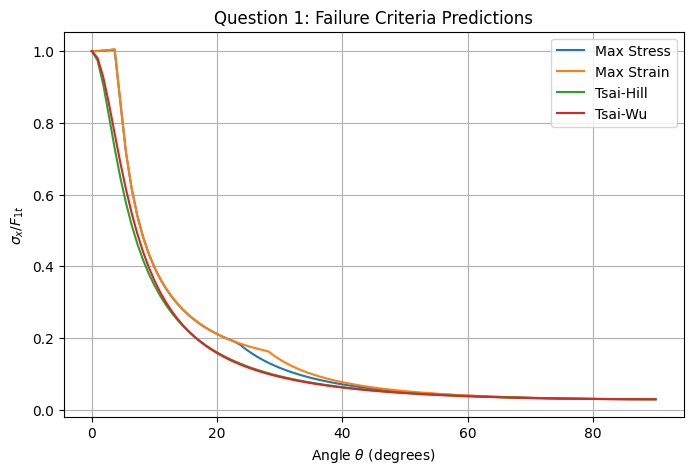


--- Running Question 2 ---
Case  | gamma_xy / N (1/Pa*m)    
-----------------------------------
1     | 2.415459e-07
2     | 1.766154e-07
3     | 1.393208e-07
4     | 1.292271e-07
5     | 1.355963e-07
6     | 1.266975e-07
7     | 1.188410e-07
8     | 1.134134e-07
9     | 1.016437e-07

--- Running Question 3 ---
[A] Matrix (N/m):
 [[46310165.37 13648725.55 15042445.96]
 [13648725.55 43217790.72 10717427.63]
 [15042445.96 10717427.63 18054676.75]]

[B] Matrix (N):
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

[D] Matrix (N·m):
 [[24.51  6.69  8.76]
 [ 6.69 11.38  3.69]
 [ 8.76  3.69  8.55]]

Stress Values at Top/Bottom of Each Layer (MPa):
Layer  | Interface | Sigma_x    | Sigma_y    | Tau_xy    
-------------------------------------------------------
1      | Top    | 121.08     | 3.75       | 1.84      
1      | Bottom | 40.36      | 1.25       | 0.61      
2      | Top    | 17.33      | -32.53     | -15.94    
2      | Bottom | -17.33     | 32.53      | 15.94     
3      | Top    | -40.36 

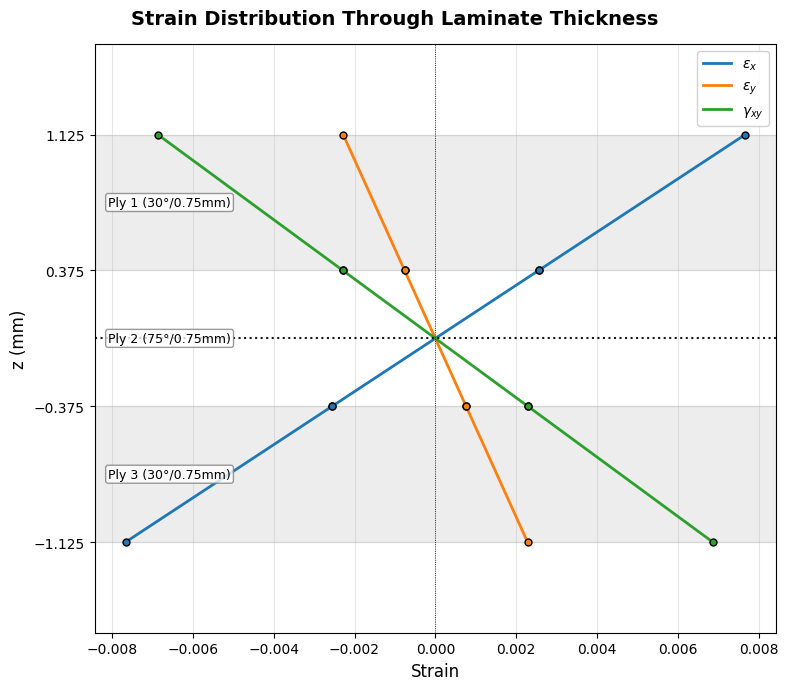

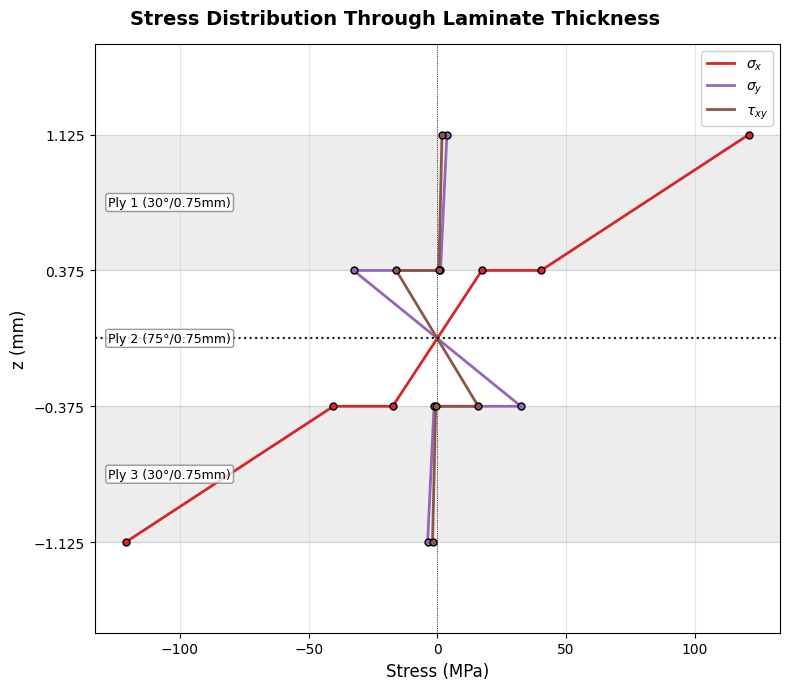


--- Running Question 4 ---
For n = 3  layers:
  Max A16/(A11*h) is 49.9380 at theta = 46.0°
  Max -D16/D11    is -0.4161 at theta = 46.0°

For n = 5  layers:
  Max A16/(A11*h) is 29.9628 at theta = 46.0°
  Max -D16/D11    is -0.2625 at theta = 46.0°

For n = 7  layers:
  Max A16/(A11*h) is 21.4020 at theta = 46.0°
  Max -D16/D11    is -0.1900 at theta = 46.0°

For n = 9  layers:
  Max A16/(A11*h) is 16.6460 at theta = 46.0°
  Max -D16/D11    is -0.1486 at theta = 46.0°

For n = 11 layers:
  Max A16/(A11*h) is 13.6195 at theta = 46.0°
  Max -D16/D11    is -0.1219 at theta = 46.0°



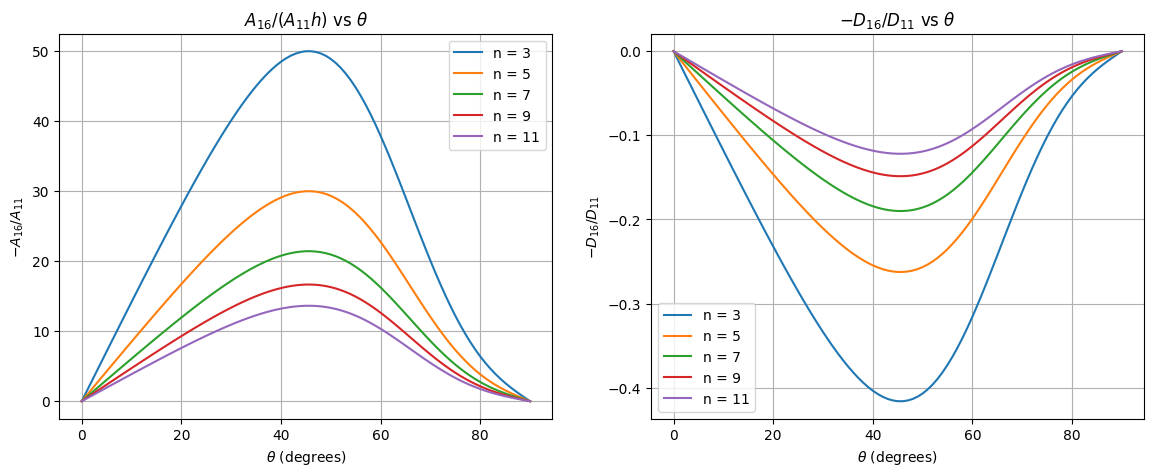

In [15]:
# Run All Questions

if __name__ == "__main__":
    question1()
    question2()
    question3()
    question4()